In [1]:
# 1. Clone your project
!git clone https://github.com/MashiroLii/Credit-Risk-PD-Model_LV1.git

# 2. Add project to Python's path
import sys
project_path = '/content/Credit-Risk-PD-Model_LV1'
if project_path not in sys.path:
    sys.path.append(project_path)

# 3. Install dependencies
!pip install xgboost lightgbm

fatal: destination path 'Credit-Risk-PD-Model_LV1' already exists and is not an empty directory.


In [2]:
%cd /content/Credit-Risk-PD-Model_LV1
!git pull

/content/Credit-Risk-PD-Model_LV1
Already up to date.


--- Running Training ---
✓ Data loaded successfully.
✓ Data preprocessing complete.
✓ Data split complete. Train set: 800 rows | Test set: 200 rows
✓ Feature scaling complete.

          STARTING MODEL BENCHMARKING

--- Training Logistic Regression ---
✓ Logistic Regression | AUC: 0.7748 | KS: 0.4833
---------------------------------------

--- Training Random Forest ---
✓ Random Forest | AUC: 0.7929 | KS: 0.4905
---------------------------------

--- Training XGBoost ---
✓ XGBoost | AUC: 0.7762 | KS: 0.4381
---------------------------

            BENCHMARKING SUMMARY
                 Model       AUC        KS
0        Random Forest  0.792917  0.490476
1              XGBoost  0.776190  0.438095
2  Logistic Regression  0.774762  0.483333

✓ Benchmarking complete.

--- Generating Plot ---

✓ ROC curve comparison chart saved to 'model_benchmark_roc_curves.png'


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:56:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


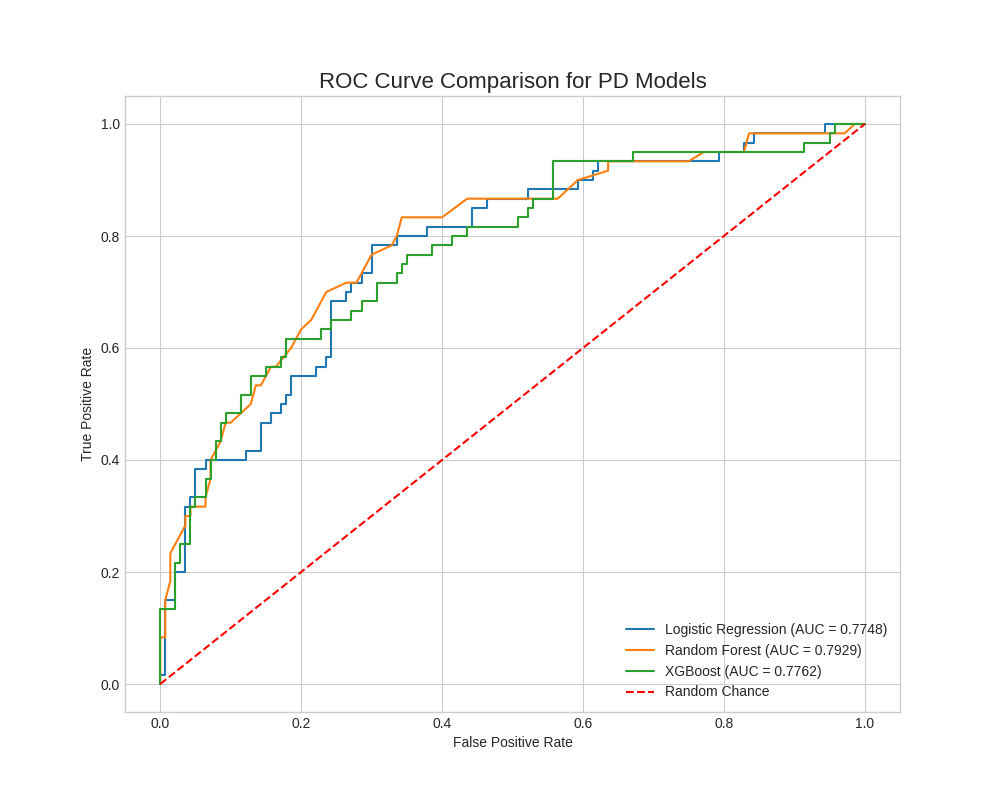

In [3]:
from src.train import run_training, plot_roc_curves
from IPython.display import Image
import importlib

# Reload the module to be sure we have the latest version
from src import train
importlib.reload(train)

print("--- Running Training ---")
results_from_run = train.run_training()

print("\n--- Generating Plot ---")
train.plot_roc_curves(results_from_run)

Image('model_benchmark_roc_curves.png')

In [7]:
%cd /content/Credit-Risk-PD-Model_LV1
!git pull

/content/Credit-Risk-PD-Model_LV1
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.18 KiB | 1.18 MiB/s, done.
From https://github.com/MashiroLii/Credit-Risk-PD-Model_LV1
   387d3bd..3915100  main       -> origin/main
Updating 387d3bd..3915100
Fast-forward
 src/scorecard.py | 14 ++++++--------
 1 file changed, 6 insertions(+), 8 deletions(-)


--- Running Scorecard Generation ---

        GENERATING CREDIT SCORECARD

✓ Data loaded successfully.
✓ Data preprocessing complete.
✓ Data split complete. Train set: 800 rows | Test set: 200 rows
✓ Feature scaling complete.
--- Training the best performing model: Random Forest ---
✓ Best model trained successfully.

--- Generating predictions and scores ---
✓ Scores generated successfully.

--- Grade Cutoffs based on Score Quantiles ---
Grade A (Top 20%): Score >= 779
Grade B (20%-40%): Score >= 718
Grade C (40%-60%): Score >= 655
Grade D (60%-80%): Score >= 575
Grade E (Bottom 20%): Score < 575

✓ Grades assigned successfully.

                     CREDIT SCORECARD ANALYSIS (Quantile-based)
       Min_Score  Max_Score  Count  Default_Count Default_Rate
Grade                                                         
A            784        839     40              4       10.00%
B            718        778     45              4        8.89%
C            657        712     35           

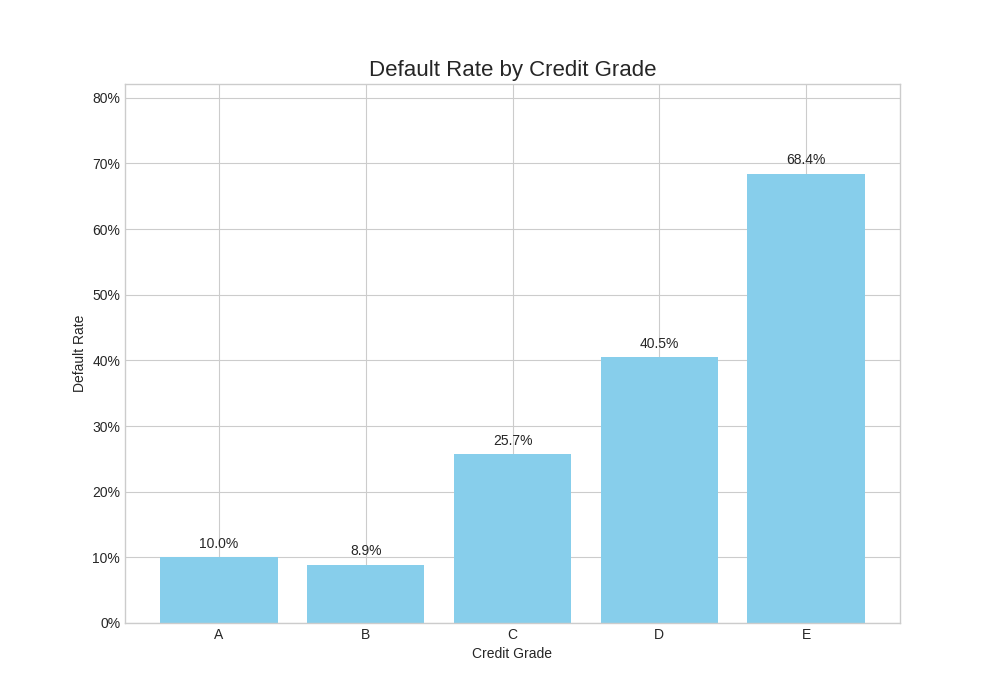

In [8]:
# Import the functions we need
from src.scorecard import run_scorecard_generation, plot_grade_analysis
from IPython.display import Image
import importlib

# Reload the module to get the latest version
from src import scorecard
importlib.reload(scorecard)

print("--- Running Scorecard Generation ---")
# Run the generation function and CAPTURE its output
stats_from_run = scorecard.run_scorecard_generation()

print("\n--- Generating Plot ---")
# Pass the captured stats to the plotting function
scorecard.plot_grade_analysis(stats_from_run)

# Display the generated image
Image('scorecard_grade_analysis.png')